### Create parameter sweep notebook

In [1]:
import sys
import os

# Get the path to the project root (adjust the number of '..' as needed)
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Add the project root to the system path
if project_root not in sys.path:
    sys.path.append(project_root)
print("Project root added to sys.path:", project_root)

Project root added to sys.path: /Users/admin/Desktop/Data Science/Trading-Bot


In [2]:
import pandas as pd

from src.backtest.walk_forward import walk_forward_test

df = pd.read_parquet("../data/processed/btc_1h.parquet")

results = []

for fast in [8, 12, 16]:
    for slow in [20, 26, 32]:
        if fast >= slow:
            continue

        stats = walk_forward_test(df)

        results.append({
            "fast": fast,
            "slow": slow,
            **stats
        })

results_df = pd.DataFrame(results)
results_df.sort_values("sharpe", ascending=False)


,fast,slow,total_return,sharpe,win_rate,max_drawdown,num_trades
0,8,20,0.318207,0.600521,0.487481,-0.265535,394
1,8,26,0.318207,0.600521,0.487481,-0.265535,394
2,8,32,0.318207,0.600521,0.487481,-0.265535,394
3,12,20,0.318207,0.600521,0.487481,-0.265535,394
4,12,26,0.318207,0.600521,0.487481,-0.265535,394
5,12,32,0.318207,0.600521,0.487481,-0.265535,394
6,16,20,0.318207,0.600521,0.487481,-0.265535,394
7,16,26,0.318207,0.600521,0.487481,-0.265535,394
8,16,32,0.318207,0.600521,0.487481,-0.265535,394


In [3]:
import pandas as pd

from src.backtest.walk_forward import walk_forward_test

df = pd.read_parquet("../data/processed/btc_1h.parquet")

results = []

for fast in [8, 12, 16]:
    for slow in [20, 26, 32]:
        if fast >= slow:
            continue

        #stats = walk_forward_test(df)
        # Pass the current parameters to the function
        stats = walk_forward_test(df, fast=fast, slow=slow) 

        results.append({
            "fast": fast,
            "slow": slow,
            **stats
        })

results_df = pd.DataFrame(results)
results_df.sort_values("sharpe", ascending=False)


,fast,slow,total_return,sharpe,win_rate,max_drawdown,num_trades
6,16,20,0.389483,0.677190,0.488819,-0.292545,398
4,12,26,0.318207,0.600521,0.487481,-0.265535,394
7,16,26,0.266491,0.542339,0.491495,-0.331453,337
2,8,32,0.161897,0.416762,0.484996,-0.231260,442
3,12,20,0.153486,0.406166,0.485092,-0.287288,470
5,12,32,0.124673,0.369457,0.490252,-0.380486,355
0,8,20,0.105866,0.344787,0.481938,-0.296855,558
1,8,26,0.042297,0.258601,0.482511,-0.279852,500
8,16,32,0.024456,0.233581,0.491495,-0.400326,305


### After plots.py

In [6]:
from src.features.technical import add_technical_features
from src.backtest.ma_crossover import ma_crossover_strategy
from src.bot.paper_exchange import PaperExchange # Use this if you want an exact equity calculation

# 1. Load the raw data (already done in your code)
df = pd.read_parquet("../data/processed/btc_1h.parquet")

# 2. Add technical features (EMAs, returns, etc.)
# Note: You need to make sure you have the 'return' column added first as discussed previously
df["return"] = df["close"].pct_change()
# df = add_technical_features(df) # Optional if all features are in ma_crossover_strategy

# 3. Apply the optimal strategy (using the 16/20 parameters you identified as best)
# Note: You must ensure 'ma_crossover_strategy' is imported
df_strategy = ma_crossover_strategy(df, fast=16, slow=20) 

# 4. Calculate the cumulative returns and the final equity curve
starting_balance = 500 

# The 'strategy_return' column is generated by ma_crossover_strategy
df_strategy['cumulative_return'] = (1 + df_strategy['strategy_return']).cumprod()

# Calculate the actual dollar equity value over time
df_strategy['equity'] = df_strategy['cumulative_return'] * starting_balance

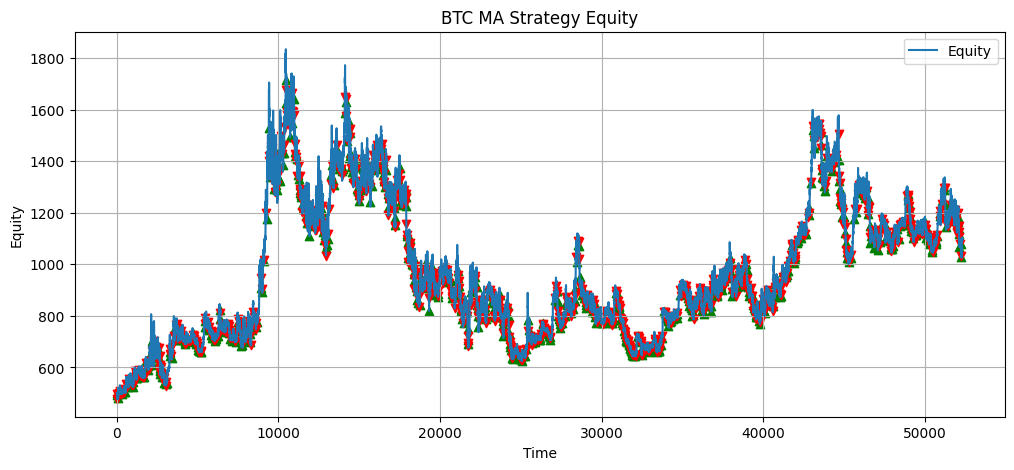

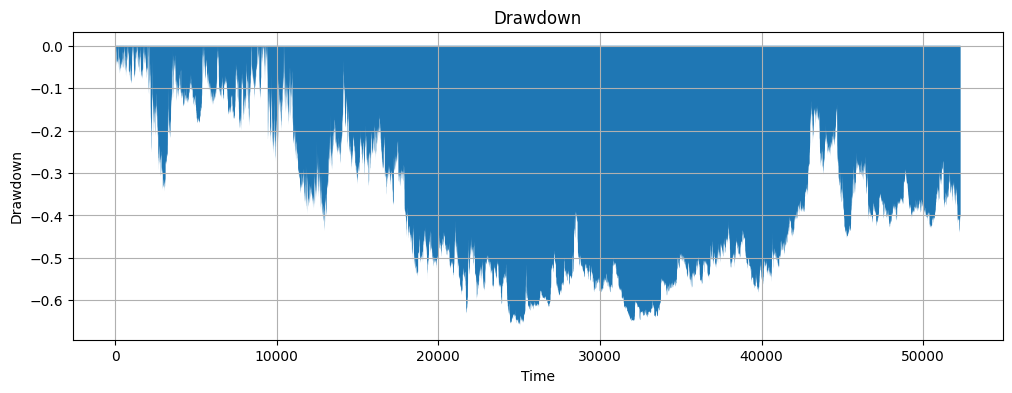

In [7]:
# 5. Now pass the *processed* DataFrame (df_strategy) to the plotting functions
from src.visualization.plots import equity_curve, drawdown_plot

equity_curve(df_strategy, "BTC MA Strategy Equity")
drawdown_plot(df_strategy)

In [9]:
#Visualize trades.csv
import pandas as pd

trades = pd.read_csv("../logs/trades.csv")
trades.head()

,timestamp,side,price,size,balance
0,timestamp,side,price,size,balance
1,2025-12-08T07:43:15.750222,BUY,91699.27,0.001,9908.30073
2,2025-12-08T07:43:16.267110,BUY,91696.44,0.001,9816.604290000001
3,2025-12-08T07:43:16.773060,BUY,91695.66,0.001,9724.908630000002
4,2025-12-08T07:43:17.228125,BUY,91695.66,0.001,9633.212970000002
